#`Project 01` Prediction of Aqueous Solubility of Small Molecules Through Regression Modeling Using Delaney Data set utilizing PyCaret 3.0
## `Author` Pritom Kundu
### B Pharm Honors | University of Rajshahi, Bangladesh | CADD Scientist I DeepBio Limited, Bangladesh
##`About The Project`
The goal of this study is to implement regression modeling to predict the aqueous solubility of small compounds by utilizing the Delaney dataset, which includes molecular descriptors and empirically determined solubility values. The procedure, which includes data preprocessing, feature selection, model comparison, and hyperparameter tuning, was streamlined using PyCaret 3.0, a low-code Python machine learning toolkit. To find the most reliable predictor, many regression models were assessed using performance indicators like R2, RMSE, and MAE. The project demonstrates the way cheminformatics challenges can be solved using machine learning approaches, offering a comprehensible and effective method to assess solubility—a crucial characteristic in drug discovery and formulation development.
### `Reference:`  [Delaney Paper](https://pubs.acs.org/doi/10.1021/ci034243x).


### `Step 01` Mounting the google drive
In this step we are going to mount our google drive so that we can easily access our needed data sets as well as store the obtained outputs in our google drive in an organized way.

In [1]:
# 01 Google Drive Mounting
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### `Step 02` Installation of required packages
In this step we are going to install three packages
- `RDkit`: For Molecular Descriptor Calculation from SMILES
- `researchpy`: For exploring summary statistics
- `PyCaret 3.0`: For Low Code Machine Learning Modeling

In [2]:
# Starting the installation
!pip install rdkit
!pip install researchpy
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-tx3dm65c
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-tx3dm65c
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### `Step 03`Importing The Needed Library
In this step we will import some of the needed packages which will help us to handle data and numarical operations

In [3]:
# 01 These are our needed libraries for this project
import pandas as pd
import numpy as np
import researchpy as rp
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [4]:
# 02 Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

### `Step 04` Loading the dataset
In this step we are going to import the delaney dataset into our project

In [5]:
# reading the data set
delaney_data = pd.read_csv("/content/drive/MyDrive/01 Academic Projects/01 Project  ESOL Prediction/Data/delaney.csv")

### `Step 5` Exploring the dataset
In this step we will explore the data set see the dataset shape, check if there any missing values in the dataset

In [6]:
# 01 Exploring how many data in our dataset
delaney_data.shape

(1144, 4)

In [7]:
# 02 Checking if there any missing values
delaney_data.isnull().sum()

,0
Compound ID,0
measured log(solubility:mol/L),0
ESOL predicted log(solubility:mol/L),0
SMILES,0


In [8]:
# 03 Checking data information
delaney_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Compound ID                           1144 non-null   object 
 1   measured log(solubility:mol/L)        1144 non-null   float64
 2   ESOL predicted log(solubility:mol/L)  1144 non-null   float64
 3   SMILES                                1144 non-null   object 
dtypes: float64(2), object(2)
memory usage: 35.9+ KB


### `Step 06` Descriptor calculations using RDKIT from SMILES
In this step we will do the following things
- We will convert our SMILES into Mol Object
- Calculate the needed descriptors for our purpose (logP,MW,AP, number of RotatableBonds)
- Preprocess and keep the final data set

In [9]:
# 01 Converting SMILES to Molecular Object
mol_obj = delaney_data['Mol'] = delaney_data['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))

In [10]:
# 02 Obseving the new data set
delaney_data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>


In [11]:
# 03 Calculating Molecular weight
delaney_data['MW'] = delaney_data['Mol'].apply(lambda x: Descriptors.MolWt(x))
delaney_data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MW
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375


In [12]:
# 03 Calculating MolLogP
delaney_data['LogP'] = delaney_data['Mol'].apply(lambda x: Descriptors.MolLogP(x))
delaney_data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MW,LogP
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850,2.5954
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405,2.3765
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850,2.5938
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405,2.0289
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375,2.9189


In [13]:
# 04 Calculating Number of Rotatable bonds
delaney_data['NRB'] = delaney_data['Mol'].apply(lambda x: Lipinski.NumRotatableBonds(x))
delaney_data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MW,LogP,NRB
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850,2.5954,0
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405,2.3765,0
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850,2.5938,1
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405,2.0289,1
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375,2.9189,1


In [14]:
# 05 Calculating Number Aromatic Atom
delaney_data['Aromatic_Atom'] = delaney_data['Mol'].apply(lambda x: Lipinski.NumAromaticRings(x))
delaney_data.head(1141)

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MW,LogP,NRB,Aromatic_Atom
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850,2.5954,0,0
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405,2.3765,0,0
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850,2.5938,1,0
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405,2.0289,1,0
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375,2.9189,1,0
...,...,...,...,...,...,...,...,...,...
1136,Urea,0.960,0.832,NC(=O)N,<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd8040>,60.056,-0.9762,0,0
1137,uric acid,-3.930,-0.541,O=c2[nH]c(=O)c1[nH]c(=O)[nH]c1[nH]2,<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd80b0>,168.112,-1.7672,0,2
1138,Valeraldehyde,-0.850,-1.103,CCCCC=O,<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd8120>,86.134,1.3755,3,0
1139,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC),<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd8190>,287.343,1.9882,8,0


In [15]:
# 06 Calculating Number Heavy Atom
delaney_data['Heavy_Atom'] = delaney_data['Mol'].apply(lambda x: Lipinski.HeavyAtomCount(x))
delaney_data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MW,LogP,NRB,Aromatic_Atom,Heavy_Atom
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850,2.5954,0,0,6
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405,2.3765,0,0,5
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850,2.5938,1,0,6
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405,2.0289,1,0,5
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375,2.9189,1,0,8


### `Step 6.1` Calculation of Aromatic Proportion (AP)
In organic chemistry, the Aromatic Proportion (AP) often referred to as the Aromaticity Index—is used to quantify the degree to which a molecule's structure is composed of aromatic rings relative to its total size.
Unfortunately the aromatic proportion cannot be calculated by default with rdkit. So we need to calculate this value by using the following equations
- $Aromatic proportion = number of aromatic atoms / total number of heavy atoms$

In [16]:
# Calculating the atomic proportion
delaney_data['AP'] = delaney_data['Aromatic_Atom'] / delaney_data['Heavy_Atom']
delaney_data.head(1141)

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol,MW,LogP,NRB,Aromatic_Atom,Heavy_Atom,AP
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850,2.5954,0,0,6,0.000000
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405,2.3765,0,0,5,0.000000
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850,2.5938,1,0,6,0.000000
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405,2.0289,1,0,5,0.000000
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375,2.9189,1,0,8,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1136,Urea,0.960,0.832,NC(=O)N,<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd8040>,60.056,-0.9762,0,0,4,0.000000
1137,uric acid,-3.930,-0.541,O=c2[nH]c(=O)c1[nH]c(=O)[nH]c1[nH]2,<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd80b0>,168.112,-1.7672,0,2,12,0.166667
1138,Valeraldehyde,-0.850,-1.103,CCCCC=O,<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd8120>,86.134,1.3755,3,0,6,0.000000
1139,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC),<rdkit.Chem.rdchem.Mol object at 0x7e77f4dd8190>,287.343,1.9882,8,0,16,0.000000


### `Step 07` Exporting The clean data set
In this step we will save our preprocessed and clean data set in order to perform further explanatory data analysis as well as Machine learning modeling

In [17]:
# 01 Renaming the target column measured log(solubility:mol/L) to LogS
delaney_data.rename(columns = {'measured log(solubility:mol/L)':'LogS'}, inplace = True)
delaney_data.head()

,Compound ID,LogS,ESOL predicted log(solubility:mol/L),SMILES,Mol,MW,LogP,NRB,Aromatic_Atom,Heavy_Atom,AP
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4b30>,167.850,2.5954,0,0,6,0.0
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4a50>,133.405,2.3765,0,0,5,0.0
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4ba0>,167.850,2.5938,1,0,6,0.0
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4cf0>,133.405,2.0289,1,0,5,0.0
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7e77f4da4d60>,187.375,2.9189,1,0,8,0.0


In [18]:
# 02 Extracting just needed Collumns only
clean_data = delaney_data[["Compound ID","SMILES",'MW', 'LogP', 'NRB', 'AP', 'LogS']]
clean_data.head()

,Compound ID,SMILES,MW,LogP,NRB,AP,LogS
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,167.850,2.5954,0,0.0,-2.18
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,133.405,2.3765,0,0.0,-2.00
2,"1,1,2,2-Tetrachloroethane",ClC(Cl)C(Cl)Cl,167.850,2.5938,1,0.0,-1.74
3,"1,1,2-Trichloroethane",ClCC(Cl)Cl,133.405,2.0289,1,0.0,-1.48
4,"1,1,2-Trichlorotrifluoroethane",FC(F)(Cl)C(F)(Cl)Cl,187.375,2.9189,1,0.0,-3.04


In [19]:
# 03 Saving the clean dataset
file_path = "/content/drive/MyDrive/01 Academic Projects/01 Project  ESOL Prediction/Output/Clean_Esol_data"
clean_data.to_csv(file_path, index=False)

### `Step 8` Explanatory data analysis
In this step we will explore some univariate summary statistics along with some statistical visualization that will give us an over all idea about our data set


In [20]:
# 01 Exploring the summary statistics with researchpy
rp.summary_cont(clean_data.drop(columns=['Compound ID', 'SMILES'])) # 'Compound ID', 'SMILES' aren't numaric values

,Variable,N,Mean,SD,SE,95% Conf.,Interval
0,MW,1144.0,204.6317,102.6205,3.0340,198.6788,210.5846
1,LogP,1144.0,2.4491,1.8660,0.0552,2.3409,2.5574
2,NRB,1144.0,2.1740,2.6274,0.0777,2.0215,2.3264
3,AP,1144.0,0.0652,0.0649,0.0019,0.0614,0.0690
4,LogS,1144.0,-3.0580,2.0965,0.0620,-3.1796,-2.9364


In [21]:
# 02 Exploring the corelations between variable (pearson correlation)
clean_data.drop(columns=['Compound ID', 'SMILES']).corr() # 'Compound ID', 'SMILES' aren't numaric values

,MW,LogP,NRB,AP,LogS
MW,1.000000,0.468097,0.394219,0.083605,-0.637324
LogP,0.468097,1.000000,0.205607,0.245790,-0.827959
NRB,0.394219,0.205607,1.000000,-0.306223,-0.238508
AP,0.083605,0.245790,-0.306223,1.000000,-0.278582
LogS,-0.637324,-0.827959,-0.238508,-0.278582,1.000000


In [22]:
# 03 Exploring the skewness of the variables
clean_data.drop(columns=['Compound ID', 'SMILES']).skew()

,0
MW,0.890477
LogP,-0.012982
NRB,2.158178
AP,0.587681
LogS,-0.484590


### `Step 08` Basic statistical visualization
In this step we will visualize some basic univariate analysis

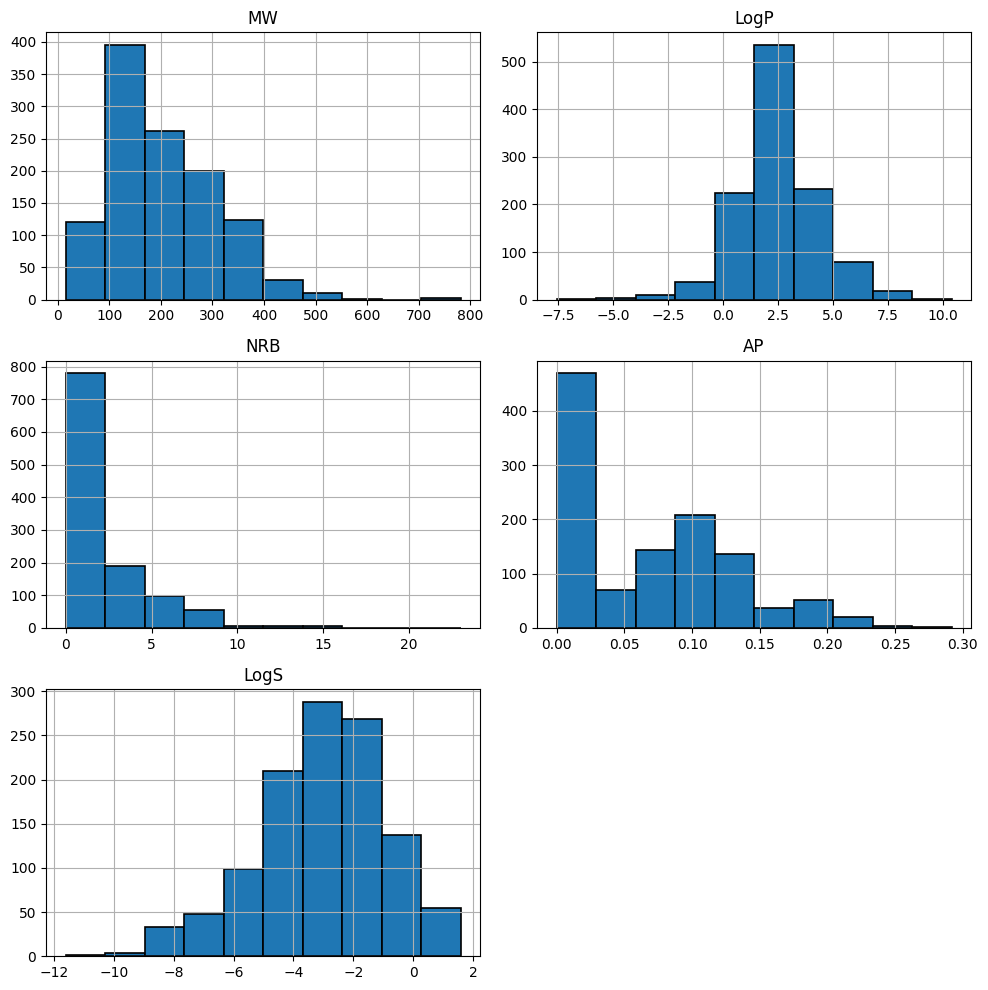

In [23]:
# 01 visualizing univariate distributions with histogram
clean_data.drop(columns=['Compound ID', 'SMILES']).hist(figsize=(10,10), edgecolor = 'black', linewidth=1.2)
plt.tight_layout()
plt.show()

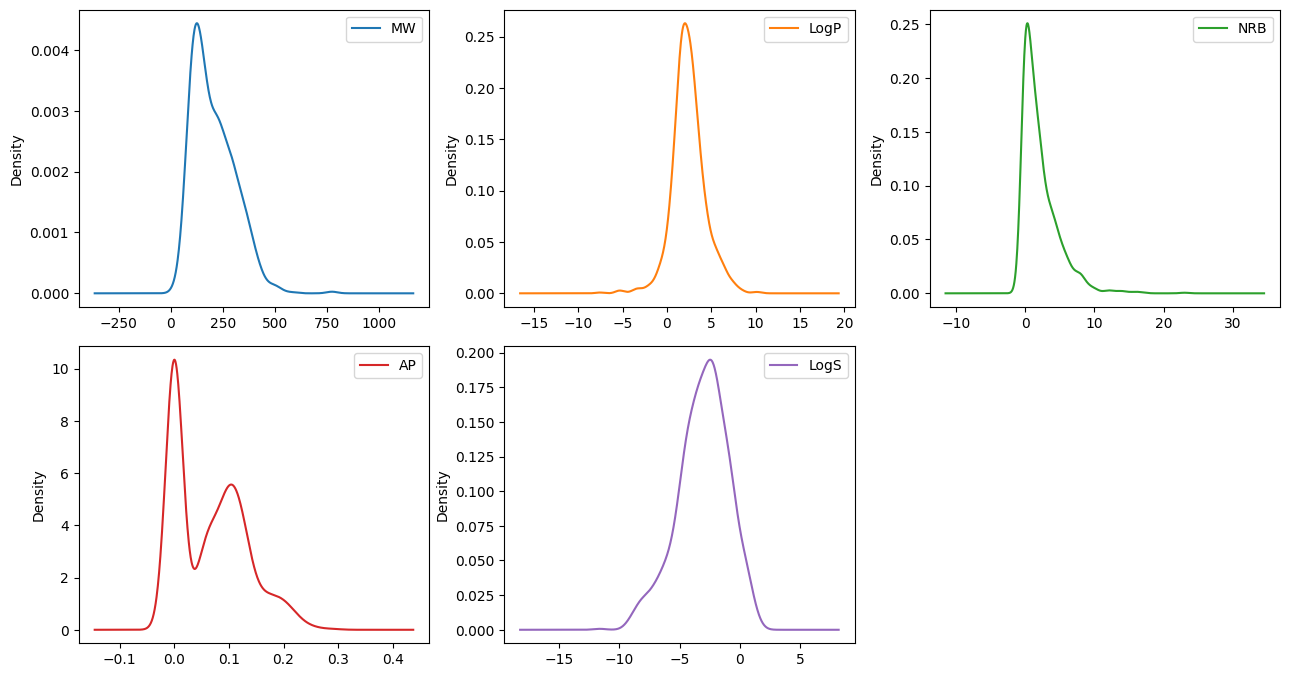

In [24]:
# 02 Univariate distribution analysis using density plot
clean_data.drop(columns=['Compound ID', 'SMILES']).plot(kind='density', subplots=True, layout=(3,3), sharex=False, figsize=(13,10))
plt.tight_layout()
plt.show()

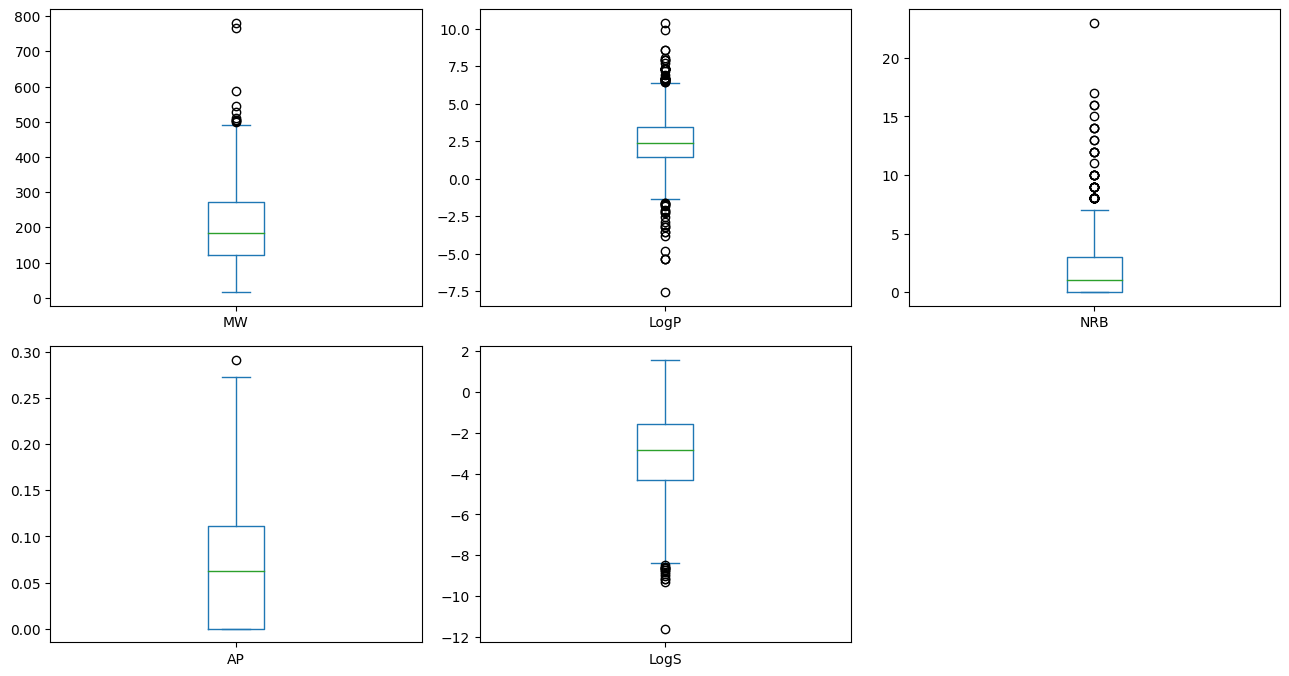

In [25]:
# 03 Univariate distribution analysis using Box plot to see the extrem values (Outliers)
clean_data.drop(columns=['Compound ID', 'SMILES']).plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(13,10))
plt.tight_layout()
plt.show()

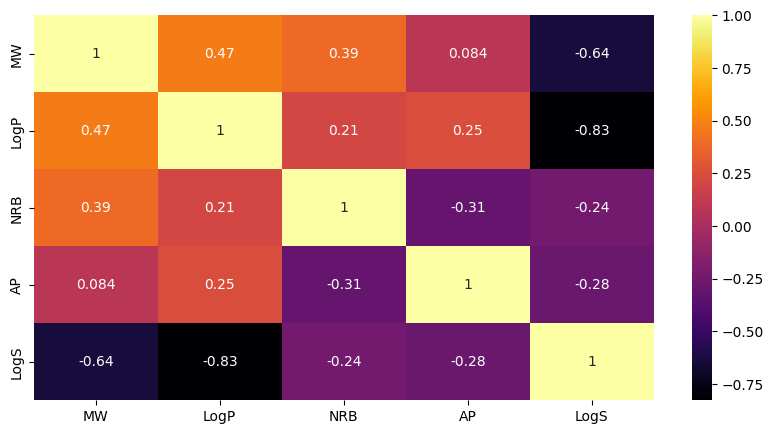

In [26]:
# 04 Multivariate analysis with correlation
plt.figure(figsize=(10,5))
sns.heatmap(clean_data.drop(columns=['Compound ID', 'SMILES']).corr(), annot=True, cmap='inferno')
plt.show()
#

In [27]:
# 05 Selecting just the numerical feature collumns and target variable for model building
model_build_data = clean_data[['MW', 'LogP', 'NRB', 'AP', 'LogS']]
model_build_data.head()

,MW,LogP,NRB,AP,LogS
0,167.850,2.5954,0,0.0,-2.18
1,133.405,2.3765,0,0.0,-2.00
2,167.850,2.5938,1,0.0,-1.74
3,133.405,2.0289,1,0.0,-1.48
4,187.375,2.9189,1,0.0,-3.04


### `Step 09` Building the model
Here we will use PyCarret 3.0 where we will build differnt type of models by training those models with our data and test them with the rest of our data and choose the best model based on evaluation matrix to obtain the best performance

In [28]:
# 01 Setting up the function of pycarret importing regression module
from pycaret.regression import *
setup(data=model_build_data, target='LogS', train_size=0.8)

,Description,Value
0,Session id,5669
1,Target,LogS
2,Target type,Regression
3,Original data shape,"(1144, 5)"
4,Transformed data shape,"(1144, 5)"
5,Transformed train set shape,"(915, 5)"
6,Transformed test set shape,"(229, 5)"
7,Numeric features,4
8,Preprocess,True
9,Imputation type,simple


In [29]:
# Checking The Features
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'transform_target_param',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [30]:
# eploring the data sets of X_train_transformed
get_config('X_train_transformed')

,MW,LogP,NRB,AP
1029,330.170990,2.88000,2.0,0.047619
1069,224.259995,0.96100,4.0,0.000000
983,314.468994,4.72350,1.0,0.000000
105,270.501007,6.24020,16.0,0.000000
1094,124.208000,2.40850,1.0,0.125000
...,...,...,...,...
1033,322.290009,3.52752,1.0,0.086957
731,362.466003,1.78160,2.0,0.000000
1042,273.722992,3.45870,1.0,0.105263
1018,129.162003,2.23480,0.0,0.200000


In [31]:
# X_test_transformed
get_config('X_test_transformed')

,MW,LogP,NRB,AP
40,114.094002,1.96480,0.0,0.125000
1010,123.114998,-0.42450,1.0,0.111111
92,169.992996,1.83140,1.0,0.000000
418,184.238007,2.76830,2.0,0.142857
1063,120.151001,1.75790,1.0,0.111111
...,...,...,...,...
194,171.037003,2.75752,0.0,0.125000
845,138.126007,1.17700,1.0,0.100000
65,122.992996,1.79130,1.0,0.000000
709,217.268005,1.77100,2.0,0.062500


In [32]:
# Y train Transformed
get_config('y_train_transformed')

,LogS
1029,-4.376
1069,-2.016
983,-4.420
105,-8.400
1094,-2.390
...,...
1033,-4.207
731,-3.090
1042,-5.360
1018,-1.300


In [33]:
# Y test transformed
get_config("y_test_transformed")

,LogS
40,-2.000
1010,-0.667
92,-2.290
418,-2.550
1063,-1.600
...,...
194,-2.230
845,-2.190
65,-1.730
709,-2.337


### `Step 10` Comparison of Different Models
Here in this step we will compare different types of model algorithm based on evaluation matrix and choose the best performing one

In [34]:
# Model compare
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4977,0.4716,0.6844,0.8910,0.1924,0.6215,0.2510
rf,Random Forest Regressor,0.5144,0.4917,0.6996,0.8865,0.2001,0.6633,0.3290
gbr,Gradient Boosting Regressor,0.5596,0.5273,0.7246,0.8793,0.2114,0.6847,0.2220
lightgbm,Light Gradient Boosting Machine,0.5436,0.5233,0.7210,0.8792,0.2073,0.6390,0.2020
xgboost,Extreme Gradient Boosting,0.5499,0.5570,0.7450,0.8718,0.2169,0.7004,0.0860
ada,AdaBoost Regressor,0.6641,0.7270,0.8503,0.8338,0.2414,0.8023,0.1440
dt,Decision Tree Regressor,0.6651,0.8641,0.9220,0.7975,0.2545,0.7774,0.0230
lr,Linear Regression,0.7557,0.9458,0.9715,0.7835,0.2895,0.8705,0.6540
lar,Least Angle Regression,0.7557,0.9458,0.9715,0.7835,0.2895,0.8705,0.0180
br,Bayesian Ridge,0.7576,0.9468,0.9720,0.7834,0.2892,0.8686,0.0180


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

### `Step 11` Creating The Best Model
From different kind of evaluation matrix we can easily see that the **Extra Trees Regressor** is appeared to be the best model for our data set. so we are going to build the model.
The rule is to choose the model which will show,
- Low MAE
- Better R2 value (More close to 1.00)

In [35]:
# Model creation
selected_model = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5283,0.4905,0.7004,0.9061,0.2085,1.1165
1,0.4711,0.4940,0.7029,0.8726,0.2046,0.3355
2,0.5229,0.4873,0.6980,0.8763,0.2061,0.3678
3,0.5650,0.5900,0.7681,0.8334,0.2153,2.0125
4,0.5619,0.5928,0.7700,0.8650,0.1811,0.3949
5,0.4568,0.3589,0.5991,0.9262,0.1770,0.4665
6,0.5015,0.4782,0.6915,0.9061,0.2189,0.5317
7,0.4566,0.3704,0.6086,0.9089,0.1685,0.3334
8,0.4789,0.4590,0.6775,0.9058,0.1557,0.2065


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [36]:
# Observing Model parameters config
selected_model

ExtraTreesRegressor(n_jobs=-1, random_state=5669)

### `Step 12` Model Analytics
Here we will try to analyze our model performances based on different type of plots


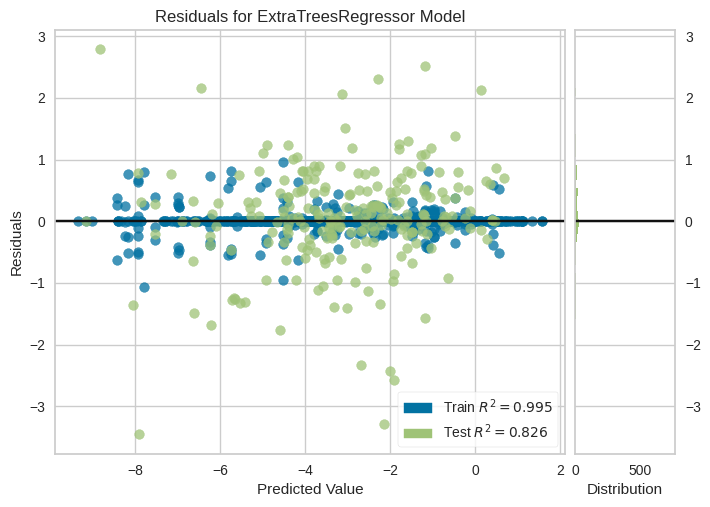

In [37]:
# Visualize the residual plot
plot_model(selected_model, plot='residuals')

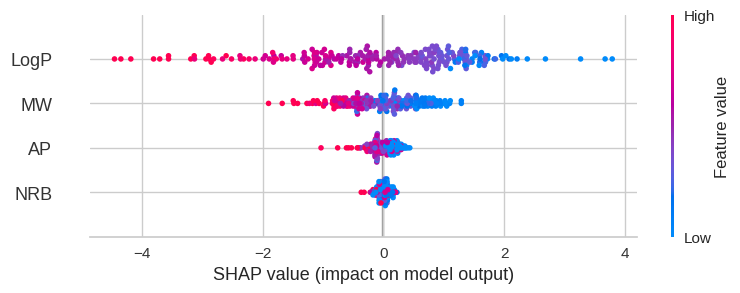

In [38]:
# Visualizing the SHAP Plot
interpret_model(selected_model)

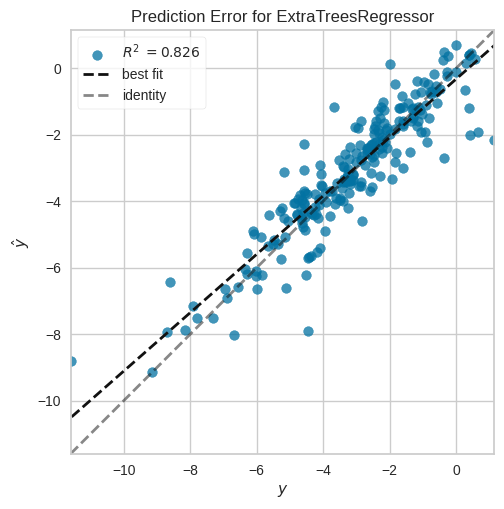

In [39]:
# 02 Visualize Error Plot
plot_model(selected_model, plot='error')

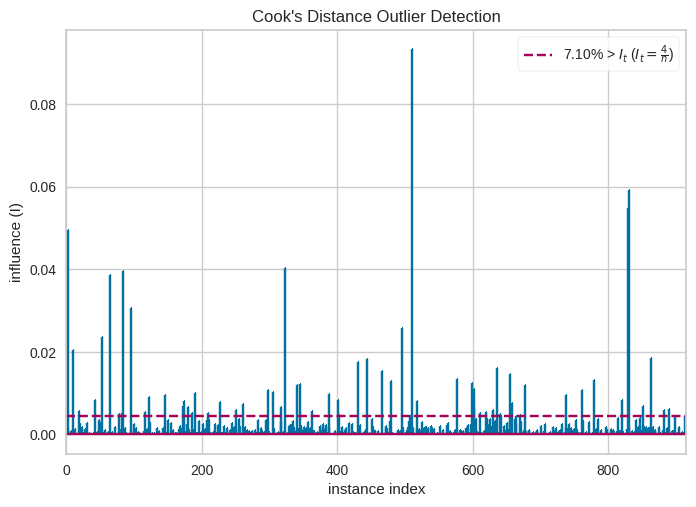

In [40]:
#  03 Visualize Cook's Index Plot
plot_model(selected_model, plot='cooks')

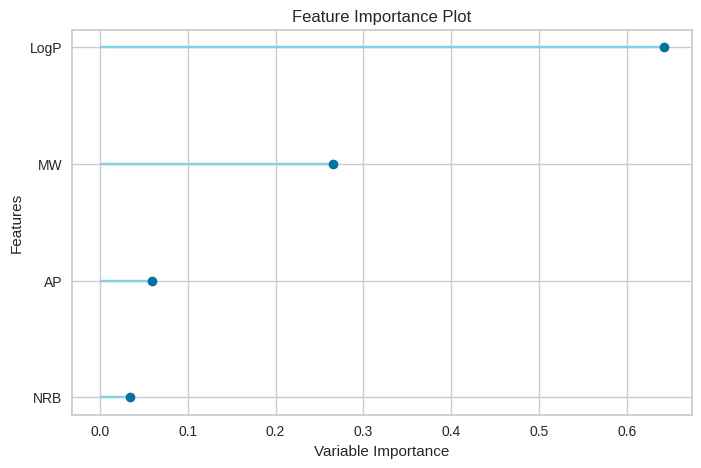

In [41]:
# 04 Visualize the feature importance plot
plot_model(selected_model, plot='feature')

### `Step 13` Model Evaluation Pipeline

In [42]:
evaluate_model(selected_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### `Step 14` Model Finalize

In [43]:
# We are finalizing our best fit model
final_model = finalize_model(selected_model)
final_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['MW', 'LogP', 'NRB', 'AP'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 ExtraTreesRegressor(n_jobs=-1, random_state=5669))])

### `Step 15` Prediction testing
Here we will use our test data set to evaluate and see how accurately our model can predict logS value

In [44]:
# Prediction test
predict_model(final_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0476,0.0194,0.1392,0.9953,0.0381,0.0228


,MW,LogP,NRB,AP,LogS,prediction_label
40,114.094002,1.96480,0,0.125000,-2.000,-1.985000
1010,123.114998,-0.42450,1,0.111111,-0.667,-0.667000
92,169.992996,1.83140,1,0.000000,-2.290,-2.290000
418,184.238007,2.76830,2,0.142857,-2.550,-2.550000
1063,120.151001,1.75790,1,0.111111,-1.600,-1.600000
...,...,...,...,...,...,...
194,171.037003,2.75752,0,0.125000,-2.230,-2.710000
845,138.126007,1.17700,1,0.100000,-2.190,-2.173333
65,122.992996,1.79130,1,0.000000,-1.730,-1.730000
709,217.268005,1.77100,2,0.062500,-2.337,-2.337000


### `Step 16` Saving the model
Here we will save the model for future uses

In [45]:
# Model Saving for future use
Model_save_path = "/content/drive/MyDrive/01 Academic Projects/01 Project  ESOL Prediction/Output/final_model"

In [46]:
# save the model to the Model_save_path
save_model(final_model, Model_save_path)

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['MW', 'LogP', 'NRB', 'AP'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('actual_estimator',
                  ExtraTreesRegressor(n_jobs=-1, random_state=5669))]),
 '/content/drive/MyDrive/01 Academic Projects/01 Project  ESOL Prediction/Output/final_model.pkl')

### `Step 17` Prediction of solubility using new unknown dataset
In this step we will use an external data set and predict the solubility  

In [47]:
# 01 Load The saved Model
saved_model = load_model(Model_save_path)
saved_model

Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['MW', 'LogP', 'NRB', 'AP'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 ExtraTreesRegressor(n_jobs=-1, random_state=5669))])

In [48]:
# 02 Define the Descriptor calculating Function
def get_molecular_features(smiles):
    """Calculates the 4 specific features used during training."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [None] * 4

    # 1. Molecular Weight
    MW = Descriptors.MolWt(mol)

    # 2. LogP (Octanol-water partition coefficient)
    LogP = Descriptors.MolLogP(mol)

    # 3. Number of Rotatable Bonds
    NRB = Lipinski.NumRotatableBonds(mol)

    # 4. Aromatic Proportion (Aromatic Atoms / Total Heavy Atoms)
    aromatic_atoms = [mol.GetAtomWithIdx(i).GetIsAromatic() for i in range(mol.GetNumAtoms())]
    num_aromatic = sum(aromatic_atoms)
    num_heavy = mol.GetNumHeavyAtoms()
    AP = num_aromatic / num_heavy if num_heavy > 0 else 0

    return [MW, LogP, NRB, AP]

print("Descriptor engine is ready.")

Descriptor engine is ready.


In [49]:
# 03 Load the data set
data = pd.read_csv("/content/drive/MyDrive/01 Academic Projects/01 Project  ESOL Prediction/Data/SMILES.csv")
data

,SMILES
0,COCOc1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O
1,C=CC(C)(C)c1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O
2,C=CC(C)(C)c1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc1O
3,C=CC(C)(C)c1c(O)cc2oc(-c3ccc(O)cc3)c(O)c(=O)c2c1O
4,O=c1c(O)c(-c2ccc(O)cc2OS(=O)(=O)O)oc2cc(O)cc(O...
5,O=C(c1ccccc1O)c1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=...
6,O=C(c1ccccc1O)c1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)...
7,O=C(c1ccccc1O)c1c(O)cc(O)c2c(=O)c(O)c(-c3ccc(O...
8,O=C(/C=C/c1ccc(O)cc1)Oc1cc(O)ccc1-c1oc2cc(O)cc...
9,CC(=O)Oc1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O


In [50]:
# 04 Applying the function to the files

feature_data = data['SMILES'].apply(get_molecular_features).tolist()
feature_df = pd.DataFrame(feature_data, columns=['MW', 'LogP', 'NRB', 'AP'])

# Combine original data with the new descriptors
final_df = pd.concat([data, feature_df], axis=1)

print("Descriptors calculated. Preview:")
final_df

Descriptors calculated. Preview:


,SMILES,MW,LogP,NRB,AP
0,COCOc1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O,346.291,2.2651,4,0.640000
1,C=CC(C)(C)c1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O,354.358,3.7460,3,0.615385
2,C=CC(C)(C)c1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc1O,354.358,3.7460,3,0.615385
3,C=CC(C)(C)c1c(O)cc2oc(-c3ccc(O)cc3)c(O)c(=O)c2c1O,354.358,3.7460,3,0.615385
4,O=c1c(O)c(-c2ccc(O)cc2OS(=O)(=O)O)oc2cc(O)cc(O...,382.302,1.4640,3,0.615385
5,O=C(c1ccccc1O)c1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=...,406.346,3.2190,3,0.733333
6,O=C(c1ccccc1O)c1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)...,406.346,3.2190,3,0.733333
7,O=C(c1ccccc1O)c1c(O)cc(O)c2c(=O)c(O)c(-c3ccc(O...,406.346,3.2190,3,0.733333
8,O=C(/C=C/c1ccc(O)cc1)Oc1cc(O)ccc1-c1oc2cc(O)cc...,448.383,3.6068,4,0.666667
9,CC(=O)Oc1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O,344.275,2.2077,2,0.640000


In [51]:
# 05 Running the prediction
predictions = predict_model(saved_model, data=final_df)
output_cols = ['SMILES', 'MW', 'LogP', 'NRB', 'AP', 'prediction_label']
results = predictions[output_cols]
results

,SMILES,MW,LogP,NRB,AP,prediction_label
0,COCOc1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O,346.290985,2.2651,4,0.640000,-4.405220
1,C=CC(C)(C)c1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O,354.358002,3.7460,3,0.615385,-5.011687
2,C=CC(C)(C)c1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc1O,354.358002,3.7460,3,0.615385,-5.011687
3,C=CC(C)(C)c1c(O)cc2oc(-c3ccc(O)cc3)c(O)c(=O)c2c1O,354.358002,3.7460,3,0.615385,-5.011687
4,O=c1c(O)c(-c2ccc(O)cc2OS(=O)(=O)O)oc2cc(O)cc(O...,382.302002,1.4640,3,0.615385,-3.897037
5,O=C(c1ccccc1O)c1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=...,406.346008,3.2190,3,0.733333,-4.832980
6,O=C(c1ccccc1O)c1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)...,406.346008,3.2190,3,0.733333,-4.832980
7,O=C(c1ccccc1O)c1c(O)cc(O)c2c(=O)c(O)c(-c3ccc(O...,406.346008,3.2190,3,0.733333,-4.832980
8,O=C(/C=C/c1ccc(O)cc1)Oc1cc(O)ccc1-c1oc2cc(O)cc...,448.382996,3.6068,4,0.666667,-4.837810
9,CC(=O)Oc1cc(O)ccc1-c1oc2cc(O)cc(O)c2c(=O)c1O,344.274994,2.2077,2,0.640000,-4.237817


In [52]:
# 06 Saving the predicted output
results.to_excel('Solubility_Results.xlsx', index=False)